# Churn Prediction | Modelagem e Tracking de Experimentos
**Objetivo:** Treinar, comparar e registrar 4 algoritmos de classificação usando MLflow para rastreamento de experimentos.  
**Modelos:** Logistic Regression · Random Forest · XGBoost · LightGBM  
**Métrica principal:** AUC-ROC (Por conta do dataset desbalanceado 73/27 como visto na exploração)

## 0. Imports

In [1]:
import os
import warnings
import logging
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix, RocCurveDisplay)

## 1. Carregamento dos datasets e configuração do MLflow
Os dados e o preprocessor foram gerados no pré-procesamento não há reprocessamento aqui.  
O preprocessor é carregado para aplicar `transform` (nunca `fit_transform`) nos dados de entrada.

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
preprocessor = joblib.load('../models/preprocessor.pkl')

# transform apenas, fit foi feito exclusivamente no treino 
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Train: {X_train_proc.shape} | Test: {X_test_proc.shape}")

Train: (5634, 26) | Test: (1409, 26)


In [3]:
# Retirar avisos de UserWarning e logs verbose do MLflow
warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger('mlflow').setLevel(logging.ERROR)

os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
os.makedirs('../mlruns', exist_ok=True)
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('churn-prediction')
print('MLflow configurado.')

MLflow configurado.


## 2. Definição dos modelos e função de avaliação
Uma função centralizada `evaluate_and_log` encapsula o ciclo completo: treino, predição, cálculo de métricas e log no MLflow.  
Isso garante que todos os modelos sejam avaliados sob as mesmas condições e que cada run seja rastreável.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':            XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM':           LGBMClassifier(random_state=42, verbose=-1)
}

def evaluate_and_log(name, model, X_tr, y_tr, X_te, y_te):
    with mlflow.start_run(run_name=name):
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]

        metrics = {
            'auc_roc':   round(roc_auc_score(y_te, y_proba), 4),
            'f1':        round(f1_score(y_te, y_pred), 4),
            'precision': round(precision_score(y_te, y_pred), 4),
            'recall':    round(recall_score(y_te, y_pred), 4),
        }
        # CV AUC mede estabilidade do modelo entre folds e é menos suscetível a overfitting
        cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='roc_auc').mean()
        metrics['cv_auc_mean'] = round(cv_auc, 4)

        mlflow.log_metrics(metrics)
        mlflow.log_params(model.get_params())
        mlflow.sklearn.log_model(model, name)

        print(f"{name:20s} | AUC: {metrics['auc_roc']} | F1: {metrics['f1']} | CV AUC: {metrics['cv_auc_mean']}")
        return metrics, model

## 3. Treinamento dos modelos
Cada modelo é treinado, avaliado e logado em uma run separada no MLflow.  
Os resultados ficam armazenados em `results`  e `trained_models`.

In [5]:
results = {}
trained_models = {}

for name, model in models.items():
    metrics, fitted = evaluate_and_log(
        name, model,
        X_train_proc, y_train,
        X_test_proc,  y_test
    )
    results[name] = metrics
    trained_models[name] = fitted

LogisticRegression   | AUC: 0.8468 | F1: 0.5822 | CV AUC: 0.8486
RandomForest         | AUC: 0.821 | F1: 0.5345 | CV AUC: 0.8243
XGBoost              | AUC: 0.8163 | F1: 0.5402 | CV AUC: 0.8247
LightGBM             | AUC: 0.8331 | F1: 0.5685 | CV AUC: 0.8364


## 4. Comparação de métricas
Tabela ordenada por AUC-ROC. A coluna `cv_auc_mean` valida que o desempenho no teste é estável e não produto de overfitting.

                    auc_roc      f1  precision  recall  cv_auc_mean
LogisticRegression   0.8468  0.5822     0.6678  0.5160       0.8486
LightGBM             0.8331  0.5685     0.6250  0.5214       0.8364
RandomForest         0.8210  0.5345     0.6096  0.4759       0.8243
XGBoost              0.8163  0.5402     0.5839  0.5027       0.8247


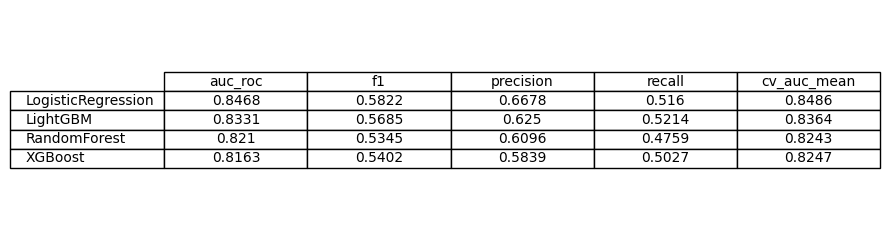

In [6]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('auc_roc', ascending=False)
print(results_df.to_string())

# Salvar tabela como figura, para usar no README
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')
tbl = ax.table(cellText=results_df.round(4).values,
               colLabels=results_df.columns,
               rowLabels=results_df.index,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
plt.tight_layout()
plt.savefig('../data/figures/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Curvas ROC
Sobreposição das curvas ROC dos 4 modelos. Quanto mais próxima do canto superior esquerdo, melhor o poder discriminativo do modelo.

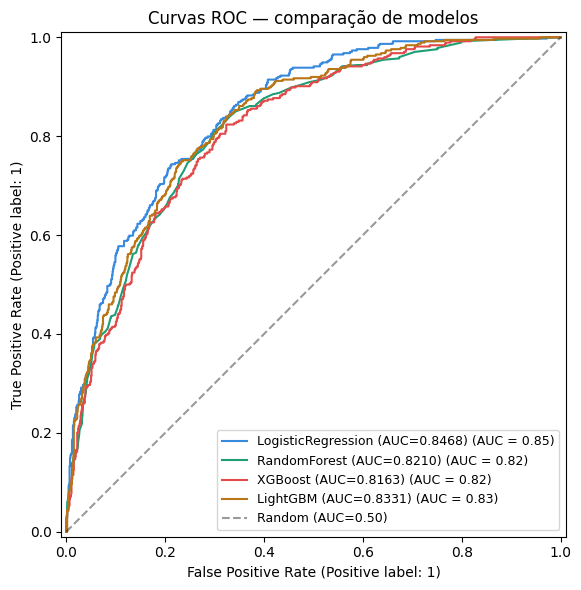

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#378ADD', '#1D9E75', '#E24B4A', '#BA7517']
for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    viz = RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=f"{name} (AUC={results[name]['auc_roc']:.4f})",
        ax=ax
    )
    viz.line_.set_color(color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.50)')
ax.set_title('Curvas ROC — comparação de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/figures/06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Matriz de confusão
A matriz detalha os erros do modelo: falsos positivos (clientes que não cancelariam mas foram sinalizados) e falsos negativos (clientes que cancelaram e não foram detectados).  
Em cenários de churn, **falsos negativos costumam ser mais custosos**, pois perderíamos um cliente sem acionar retenção.

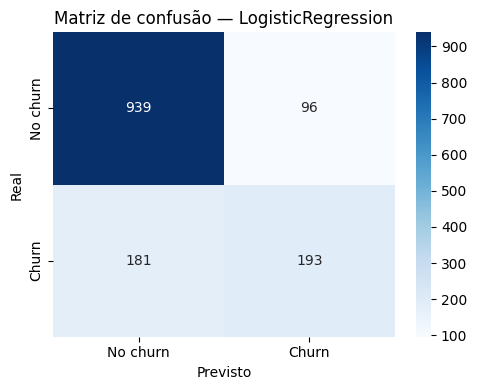


Melhor modelo: LogisticRegression


In [8]:
best_name = results_df.index[0]
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test_proc)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No churn', 'Churn'],
            yticklabels=['No churn', 'Churn'], ax=ax)
ax.set_title(f'Matriz de confusão — {best_name}')
ax.set_ylabel('Real')
ax.set_xlabel('Previsto')
plt.tight_layout()
plt.savefig('../data/figures/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMelhor modelo: {best_name}")

## 7. Persistência do melhor modelo

In [9]:
# Salvar modelo para uso no app Streamlit
joblib.dump(best_model, '../models/best_model.pkl')
print(f"Modelo '{best_name}' salvo em models/best_model.pkl")

Modelo 'LogisticRegression' salvo em models/best_model.pkl


## 8. Resultados e insights

- **Melhor modelo:** Regressão Logística com AUC-ROC de 0.85
- Todos os modelos superam o baseline aleatório (AUC=0.5) com folga 
- CV AUC ≈ Test AUC em todos os modelos → ausência de overfitting significativo
- Regressão Logística superou modelos de ensemble neste dataset 
- Precision vs Recall: o threshold padrão (0.5) pode ser ajustado conforme o custo de negócio quanto menor threshold aumenta recall (detecta mais churns) ao custo de mais falsos positivos